1000


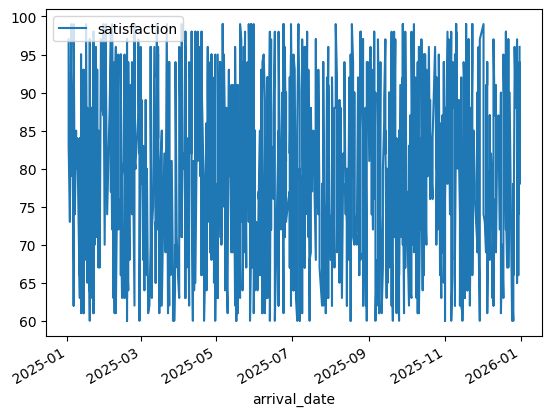

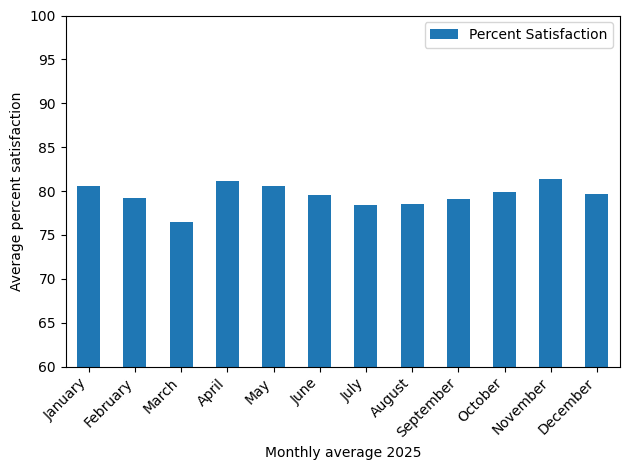

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/hospital-beds-management/patients.csv")
df["arrival_date"] = pd.to_datetime(df['arrival_date'])
df = df.sort_values('arrival_date')

# Line plot
df.plot.line(x='arrival_date', y='satisfaction')

# Create groups
df['timeGroup'] = pd.cut(df['arrival_date'], 12)
grouped = df.groupby('timeGroup', observed=False)['satisfaction'].mean().reset_index()

# Bar plot
ax = grouped.plot.bar(
    x='timeGroup',
    y='satisfaction',
    ylim=(60, 100),
    ylabel="Average percent satisfaction",
    xlabel="Monthly average 2025",
    label="Percent Satisfaction"
)

# Add custom x-tick labels
MONTHS = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
print(len(df))
# Set xticks and labels
ax.set_xticks(range(len(MONTHS)))
ax.set_xticklabels(MONTHS, rotation=45, ha='right')

plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

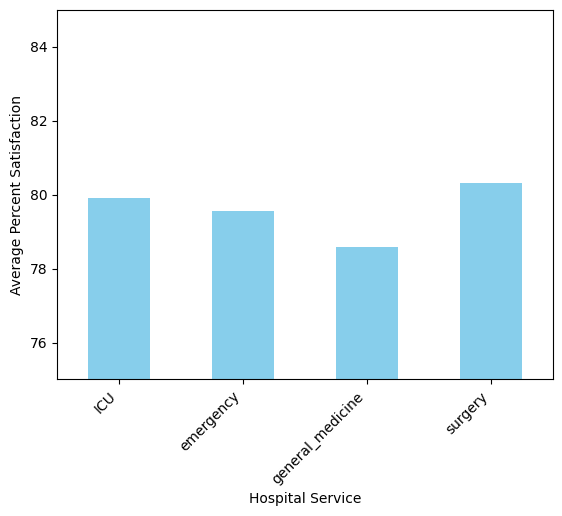

In [3]:
import pandas as pd
patients_df = pd.read_csv("/kaggle/input/hospital-beds-management/patients.csv")

# Group by service and calculate mean satisfaction
service_grouped = patients_df.groupby('service')['satisfaction'].mean().reset_index()

# Plot the average satisfaction per service
ax = service_grouped.plot.bar(
    x='service', 
    y='satisfaction', 
    ylim=(75, 85), 
    ylabel="Average Percent Satisfaction", 
    xlabel="Hospital Service",
    legend=False,
    color='skyblue'
)

# Rotate labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


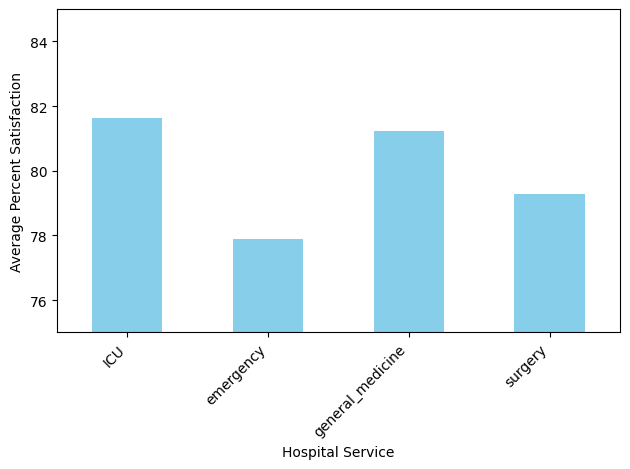

In [12]:
weekly_services_df = pd.read_csv("/kaggle/input/hospital-beds-management/services_weekly.csv")

# Group by service and calculate mean satisfaction
service_grouped = weekly_services_df.groupby('service')['patient_satisfaction'].mean().reset_index()

# Plot the average satisfaction per service
ax = service_grouped.plot.bar(
    x='service', 
    y='patient_satisfaction', 
    ylim=(75, 85), 
    ylabel="Average Percent Satisfaction", 
    xlabel="Hospital Service",
    legend=False,
    color='skyblue'
)

# Rotate labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [20]:
import pandas as pd
import plotly.express as px

# I had trouble making my map display in kaggle so I found this solution online
import plotly.io as pio
pio.renderers.default = 'iframe_connected'

data = pd.DataFrame({
    'country': ['United States', 'Canada', 'Mexico', 'Brazil', 'France'],
    'value': [100, 80, 60, 90, 70]
})

fig = px.choropleth(
    data,
    locations='country',
    locationmode='country names',
    color='value',
    color_continuous_scale='Blues',
    title='Choropleth Map by Country'
)
fig.show()

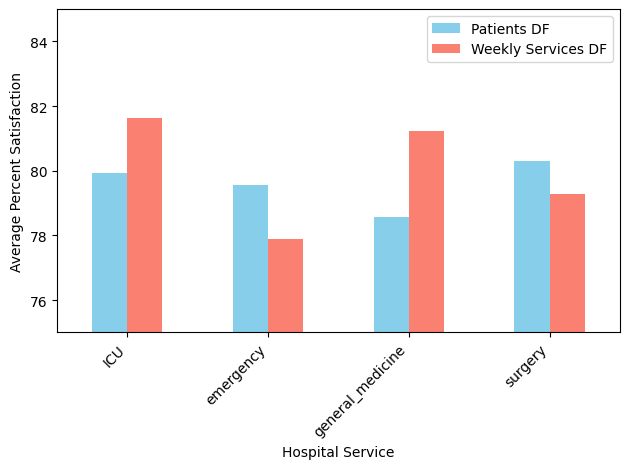

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
patients_df = pd.read_csv('/kaggle/input/hospital-beds-management/patients.csv')
weekly_services_df = pd.read_csv('/kaggle/input/hospital-beds-management/services_weekly.csv')

# 2. Group and calculate means for both dataframes
# (Assuming 'service', 'patient_satisfaction', and 'satisfaction' are the exact column names)
patients_grouped = patients_df.groupby('service')['satisfaction'].mean().reset_index()
services_grouped = weekly_services_df.groupby('service')['patient_satisfaction'].mean().reset_index()

# 3. Merge the two DataFrames together on the 'service' column
combined_df = pd.merge(patients_grouped, services_grouped, on='service', how='inner')

# 4. Plot both columns on the same chart
ax = combined_df.plot.bar(
    x='service', 
    y=['satisfaction', 'patient_satisfaction'], 
    ylim=(75, 85), 
    ylabel='Average Percent Satisfaction', 
    xlabel='Hospital Service', 
    color=['skyblue', 'salmon']
)

# 5. Customize legend and labels
ax.legend(['Patients DF', 'Weekly Services DF'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


Despite both files coming from the same timeframe and same hospital, there are major differences in satisfaction. I believe this stems from repeat patients that experience multiple services under this hospital system. The differences thus hold valuble information: the satisfaction of those who most use the services are hosted in weekly services dataframe, while the satisfaction of the all patients weighted equally is held in the patients dataframe.